# Track A - Double-Pendulum Trig-SINDy PPO Checkpoint Sweep

This notebook preserves the validated SINDy-LQR flow, then adds a focused experiment for the open question from the presentation: can PPO trained inside the learned SINDy surrogate transfer back to real MuJoCo if we use checkpointing and small surrogate-side action regularization?

The main path remains pure PPO-in-surrogate transfer. LQR is kept as the validated reference controller and as the data-collection controller already used by Track A; residual PPO is included only as an optional fallback/robustness branch.

## 0. Imports And Run Switches

The PPO section is now organized as a checkpoint/sweep experiment:

- save PPO checkpoints at fixed surrogate-training levels;
- evaluate each checkpoint in real MuJoCo;
- sweep a small action-effort penalty inside the surrogate reward;
- keep residual PPO around LQR optional and clearly separate.

The existing SINDy-LQR result is left intact as the transfer baseline.

In [1]:
import pathlib
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysindy as ps
from gymnasium import spaces
from scipy.linalg import solve_discrete_are
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore", category=UserWarning)

# Optional/expensive stages.
RUN_GEOMETRY_CHECK = True
RUN_TRUE_LINEARIZATION_DIAGNOSTIC = False
RUN_ACTIVE_REFINEMENT = True
RUN_FINAL_LQR_ASSERT = True
RUN_PPO_AFTER_LQR = True

# Run the planned PPO sweep. Set False when only debugging earlier notebook cells.
RUN_PPO_CHECKPOINT_SWEEP = True
RUN_RESIDUAL_PPO_FALLBACK = False

# MuJoCo and state dimensions.
_env = gym.make("InvertedDoublePendulum-v5")
DT = _env.unwrapped.dt
_env.close()

STATE_DIM = 6
ACTION_DIM = 1
ACTION_LOW = -1.0
ACTION_HIGH = 1.0

# MuJoCo model geometry for Gymnasium InvertedDoublePendulum-v5.
L1, L2 = 0.6, 0.6
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_TARGET = 2.0
HEALTHY_REWARD = 10.0

# SINDy/data settings. Raise N_BOOTSTRAP_PROBES for an overnight run.
N_BOOTSTRAP_PROBES = 5_000
N_FIXED_VAL_PROBES = 1_000
SINDY_DEGREE = 2
SINDY_THRESHOLD = 1e-4
SINDY_ALPHA = 1e-5
# Previous results used "poly". Use "poly_trig" to add angle sin/cos terms.
SINDY_LIBRARY_KIND = "poly_trig"

# LQR active-learning settings.
MAX_ACTIVE_ITER = 2
N_ACTIVE_EPISODES = 5
ACTIVE_EXPLORATION_STD = 0.03
N_EVAL_EPISODES = 10

# PPO-in-surrogate checkpoint/sweep settings.
PPO_TOTAL_TIMESTEPS = 25_000
PPO_CHECKPOINT_STEPS = [3_000, 6_000, 9_000, 12_000, 15_000, 25_000]
PPO_ACTION_PENALTY_SWEEP = [0.0, 0.001, 0.005, 0.01, 0.02]
PPO_CHECKPOINT_EVAL_EPISODES = 10
PPO_SURROGATE_MAX_STEPS = 1000
PPO_RESET_NOISE_STD = 0.01
PPO_LEARNING_RATE = 3e-4
PPO_N_STEPS = 1024
PPO_BATCH_SIZE = 64
PPO_N_EPOCHS = 10
PPO_GAMMA = 0.99
PPO_ENT_COEF = 0.01

# Residual PPO fallback settings. This is not the primary experiment.
RESIDUAL_SCALES = [0.05, 0.10, 0.25]
RESIDUAL_ACTION_PENALTY_LAMBDA = 0.01

# LQR cost: Q penalizes state error, R penalizes action effort.
LQR_Q = np.diag([1.0, 1.0, 1.0, 0.1, 1.0, 1.0])
LQR_R = np.array([[0.01]])

# Guard PPO and surrogate rollouts against unsupported model extrapolation.
SURROGATE_STATE_LIMITS = np.array([2.5, 0.9, 0.9, 10.0, 12.0, 12.0], dtype=np.float64)

# Robustness diagnostics for best checkpoint and LQR comparison.
ROBUSTNESS_EVAL_EPISODES = 10
ROBUSTNESS_SCENARIOS = {
    "standard": {"angle_noise": 0.0, "velocity_noise": 0.0, "action_noise": 0.0, "impulse_step": None, "impulse": 0.0},
    "angle_noise": {"angle_noise": 0.04, "velocity_noise": 0.0, "action_noise": 0.0, "impulse_step": None, "impulse": 0.0},
    "velocity_noise": {"angle_noise": 0.0, "velocity_noise": 0.30, "action_noise": 0.0, "impulse_step": None, "impulse": 0.0},
    "action_noise": {"angle_noise": 0.0, "velocity_noise": 0.0, "action_noise": 0.03, "impulse_step": None, "impulse": 0.0},
    "mid_impulse": {"angle_noise": 0.0, "velocity_noise": 0.0, "action_noise": 0.0, "impulse_step": 100, "impulse": 0.25},
}

# Resolve repo root whether the kernel starts in repo root, notebooks/, or notebooks/Exploratory/.
CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "trackA_trig_ppo_checkpoint_sweep"
DATA_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

BOOTSTRAP_PATH = DATA_DIR / "trackA_lqr_transfer_bootstrap.npz"
FIXED_VAL_PATH = DATA_DIR / "trackA_lqr_transfer_fixed_val.npz"
PPO_SWEEP_DIR = RESULTS_DIR / "ppo_checkpoint_sweep"
PPO_SWEEP_DIR.mkdir(exist_ok=True, parents=True)

STATE_LABELS = ["x", "theta1", "theta2", "xdot", "theta1dot", "theta2dot"]

print(f"DT = {DT:.4f} s ({1 / DT:.0f} Hz)")
print(f"Bootstrap probes: {N_BOOTSTRAP_PROBES:,}")
print(f"Fixed validation probes: {N_FIXED_VAL_PROBES:,}")
print(f"SINDy library: {SINDY_LIBRARY_KIND}")
print(f"Run PPO checkpoint sweep: {RUN_PPO_CHECKPOINT_SWEEP}")
print(f"Penalty sweep: {PPO_ACTION_PENALTY_SWEEP}")

DT = 0.0500 s (20 Hz)
Bootstrap probes: 5,000
Fixed validation probes: 1,000
SINDy library: poly_trig
Run PPO checkpoint sweep: True
Penalty sweep: [0.0, 0.001, 0.005, 0.01, 0.02]


## 1. State, Geometry, And Reward Helpers

`obs_to_state6` converts Gymnasium's 9D observation into the 6D state used by SINDy.

`tip_position_from_state6` returns `(x_tip, tip_height)`. `tip_height` is MuJoCo's vertical site coordinate, stored internally as z.


In [2]:
def obs_to_state6(obs):
    """Gym 9D observation -> [x, theta1, theta2, xdot, theta1dot, theta2dot]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5],
        obs[6],
        obs[7],
    ], dtype=np.float64)


def tip_position_from_state6(s):
    """Return (x_tip, tip_height) for the double pendulum tip.

    In MuJoCo, vertical height is the z coordinate: data.site_xpos[0][2].
    In this notebook we call it tip_height so the 2D x/height geometry is clear.
    """
    x, theta1, theta2 = s[0], s[1], s[2]
    x_tip = x + L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    tip_height = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    return float(x_tip), float(tip_height)


def reward_done_from_state6(s):
    """Gymnasium-style reward and termination from the 6D SINDy state."""
    x_tip, tip_height = tip_position_from_state6(s)
    terminated = bool(tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
    dist_penalty = 0.01 * x_tip**2 + (tip_height - TIP_HEIGHT_TARGET) ** 2
    vel_penalty = 1e-3 * s[4] ** 2 + 5e-3 * s[5] ** 2
    reward = HEALTHY_REWARD * int(not terminated) - dist_penalty - vel_penalty
    return float(reward), terminated


def action_array(u):
    """Return a Gymnasium-compatible clipped 1D action array."""
    return np.array([np.clip(float(u), ACTION_LOW, ACTION_HIGH)], dtype=np.float32)


## 2. Optional Geometry Validation

This is a fail-fast check. It compares the notebook's `x_tip`, `tip_height`, and reward calculation against MuJoCo's actual tip site and private reward helper. You can turn it off with `RUN_GEOMETRY_CHECK = False`, but leave it on while changing geometry code.


In [3]:
def validate_tip_geometry(n=64, seed=123):
    """Check notebook geometry/reward against the real MuJoCo implementation."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    max_site_error = 0.0
    max_reward_error = 0.0

    for _ in range(n):
        env.reset(seed=int(rng.integers(0, 2**31)))
        s = np.array([
            rng.uniform(-1.0, 1.0),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-3.0, 3.0),
            rng.uniform(-4.0, 4.0),
            rng.uniform(-4.0, 4.0),
        ], dtype=np.float64)
        env.unwrapped.set_state(s[:3], s[3:])

        mujoco_x, _, mujoco_tip_height = env.unwrapped.data.site_xpos[0]
        formula_x, formula_tip_height = tip_position_from_state6(s)
        max_site_error = max(
            max_site_error,
            abs(formula_x - mujoco_x),
            abs(formula_tip_height - mujoco_tip_height),
        )

        terminated = bool(mujoco_tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
        mujoco_reward, _ = env.unwrapped._get_rew(mujoco_x, mujoco_tip_height, terminated)
        formula_reward, formula_done = reward_done_from_state6(s)
        max_reward_error = max(max_reward_error, abs(formula_reward - mujoco_reward))
        assert formula_done == terminated

    env.close()
    assert max_site_error < 1e-10, max_site_error
    assert max_reward_error < 1e-10, max_reward_error
    print(f"Geometry/reward check passed | max site error {max_site_error:.2e} | max reward error {max_reward_error:.2e}")


if RUN_GEOMETRY_CHECK:
    validate_tip_geometry()
else:
    print("Geometry/reward check skipped by RUN_GEOMETRY_CHECK=False")


Geometry/reward check passed | max site error 2.22e-16 | max reward error 1.78e-15


## 3. Local State-Action Probe Collection

Random rollouts mostly produce early falling trajectories. These probes directly sample the local state/action region where balancing control must work. Each sample still uses one real MuJoCo step.


In [4]:
def sample_probe_state_action(rng):
    """Return one sampled local state/action pair for SINDy identification."""
    if rng.random() < 0.80:
        state = np.array([
            rng.uniform(-0.25, 0.25),
            rng.uniform(-0.20, 0.20),
            rng.uniform(-0.20, 0.20),
            rng.uniform(-1.0, 1.0),
            rng.uniform(-1.5, 1.5),
            rng.uniform(-1.5, 1.5),
        ], dtype=np.float64)
        action = rng.uniform(-0.5, 0.5)
    else:
        state = np.array([
            rng.uniform(-0.70, 0.70),
            rng.uniform(-0.45, 0.45),
            rng.uniform(-0.45, 0.45),
            rng.uniform(-3.0, 3.0),
            rng.uniform(-4.0, 4.0),
            rng.uniform(-4.0, 4.0),
        ], dtype=np.float64)
        action = rng.uniform(-1.0, 1.0)
    return state, float(action)


def collect_state_action_probes(n, seed=0, label="probes"):
    """Collect one-step transitions from sampled states using MuJoCo set_state."""
    env = gym.make("InvertedDoublePendulum-v5")
    env.reset(seed=seed)  # Gymnasium requires reset before step, even after set_state.
    rng = np.random.default_rng(seed)
    X, U, X_next = [], [], []

    for _ in range(n):
        state, action = sample_probe_state_action(rng)
        env.unwrapped.set_state(state[:3], state[3:])
        next_obs, _, _, _, _ = env.step(action_array(action))
        next_state = obs_to_state6(next_obs)
        X.append(state)
        U.append([action])
        X_next.append(next_state)

    env.close()
    X = np.asarray(X, dtype=np.float64)
    U = np.asarray(U, dtype=np.float64)
    X_next = np.asarray(X_next, dtype=np.float64)
    print(f"[{label}] {len(X):,} one-step MuJoCo interactions")
    return X, U, X_next


def load_or_collect_npz(path, n, seed, label):
    """Load cached probes if present; otherwise collect and cache them."""
    if path.exists():
        data = np.load(path)
        X, U, X_next = data["X"], data["U"], data["X_next"]
        print(f"[{label}] loaded {len(X):,} transitions from {path}")
        return X, U, X_next

    X, U, X_next = collect_state_action_probes(n, seed=seed, label=label)
    np.savez(path, X=X, U=U, X_next=X_next)
    print(f"[{label}] saved to {path}")
    return X, U, X_next


In [5]:
X_all, U_all, Xn_all = load_or_collect_npz(
    BOOTSTRAP_PATH,
    N_BOOTSTRAP_PROBES,
    seed=42,
    label="bootstrap",
)

X_val, U_val, Xn_val = load_or_collect_npz(
    FIXED_VAL_PATH,
    N_FIXED_VAL_PROBES,
    seed=999,
    label="fixed validation",
)

print("Dataset shapes:", X_all.shape, U_all.shape, Xn_all.shape)


[bootstrap] loaded 10,000 transitions from /Users/andrewfalcone/Documents/Education/UW_AIML/ME595_Project/ME_595/data/trackA_lqr_transfer_bootstrap.npz
[fixed validation] loaded 10,000 transitions from /Users/andrewfalcone/Documents/Education/UW_AIML/ME595_Project/ME_595/data/trackA_lqr_transfer_fixed_val.npz
Dataset shapes: (10000, 6) (10000, 1) (10000, 6)


## 4. SINDy Fit And Fixed Validation Metrics

The model predicts the one-step state delta:

```text
x[k+1] - x[k] = f_sindy(x[k], u[k])
```

The fixed validation set is held constant across iterations so RMSE is comparable after each refit.


In [6]:
def make_sindy_library(kind=SINDY_LIBRARY_KIND):
    """Build the feature library used by SINDy.

    "poly" is the original baseline: degree-2 polynomial terms over the
    6D state and action. "poly_trig" keeps those polynomial terms and adds
    physically meaningful trigonometric terms for the two link angles:
    sin(theta1), cos(theta1), sin(theta2), cos(theta2), and the coupled
    angle terms sin(theta1 + theta2), cos(theta1 + theta2).
    """
    poly_library = ps.PolynomialLibrary(degree=SINDY_DEGREE, include_bias=True)
    if kind == "poly":
        return poly_library
    if kind != "poly_trig":
        raise ValueError(f"Unknown SINDY_LIBRARY_KIND: {kind}")

    angle_trig_library = ps.CustomLibrary(
        library_functions=[lambda x: np.sin(x), lambda x: np.cos(x)],
        function_names=[lambda x: f"sin({x})", lambda x: f"cos({x})"],
        include_bias=False,
    )
    coupled_angle_library = ps.CustomLibrary(
        library_functions=[
            lambda x, y: np.sin(x + y),
            lambda x, y: np.cos(x + y),
        ],
        function_names=[
            lambda x, y: f"sin({x}+{y})",
            lambda x, y: f"cos({x}+{y})",
        ],
        include_bias=False,
    )

    # PySINDy sees the model inputs as [x0..x5, u0]. Indices 1 and 2 are
    # theta1 and theta2, so the trig features stay tied to actual angles.
    return ps.GeneralizedLibrary(
        libraries=[poly_library, angle_trig_library, coupled_angle_library],
        inputs_per_library=[
            list(range(STATE_DIM + ACTION_DIM)),
            [1, 2],
            [1, 2],
        ],
    )


def fit_sindy_model(X, U, X_next, X_fixed=None, U_fixed=None, Xn_fixed=None):
    """Fit discrete-time SINDy dynamics and return the model plus metrics."""
    rng = np.random.default_rng(7)
    idx = rng.permutation(len(X))
    n_test = max(1, len(X) // 5)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    Y_delta = X_next - X
    model = ps.SINDy(
        feature_library=make_sindy_library(),
        optimizer=ps.STLSQ(
            threshold=SINDY_THRESHOLD,
            alpha=SINDY_ALPHA,
            normalize_columns=True,
        ),
    )
    model.fit(x=X[train_idx], t=1, u=U[train_idx], x_dot=Y_delta[train_idx])

    split_pred = X[test_idx] + model.predict(X[test_idx], u=U[test_idx])
    split_err = split_pred - X_next[test_idx]
    split_rmse = float(np.sqrt(np.mean(split_err**2)))
    split_component_rmse = np.sqrt(np.mean(split_err**2, axis=0))

    fixed_rmse = None
    fixed_component_rmse = None
    if X_fixed is not None:
        fixed_pred = X_fixed + model.predict(X_fixed, u=U_fixed)
        fixed_err = fixed_pred - Xn_fixed
        fixed_rmse = float(np.sqrt(np.mean(fixed_err**2)))
        fixed_component_rmse = np.sqrt(np.mean(fixed_err**2, axis=0))

    coeffs = model.coefficients()
    nonzero_terms = int(np.count_nonzero(np.abs(coeffs) > 1e-12))
    feature_count = len(model.get_feature_names())

    metrics = {
        "library_kind": SINDY_LIBRARY_KIND,
        "feature_count": feature_count,
        "split_rmse": split_rmse,
        "split_component_rmse": split_component_rmse,
        "fixed_rmse": fixed_rmse,
        "fixed_component_rmse": fixed_component_rmse,
        "nonzero_terms": nonzero_terms,
    }
    return model, metrics


def print_sindy_metrics(metrics, prefix=""):
    """Print compact SINDy quality metrics."""
    print(f"{prefix}library: {metrics['library_kind']} ({metrics['feature_count']} candidate features)")
    print(f"{prefix}split RMSE: {metrics['split_rmse']:.6f}")
    if metrics["fixed_rmse"] is not None:
        print(f"{prefix}fixed RMSE: {metrics['fixed_rmse']:.6f}")
        print(prefix + "fixed per-state RMSE:")
        for name, value in zip(STATE_LABELS, metrics["fixed_component_rmse"]):
            print(f"  {name:>9s}: {value:.6f}")
    print(f"{prefix}nonzero SINDy terms: {metrics['nonzero_terms']}")


In [7]:
sindy_model, sindy_metrics = fit_sindy_model(X_all, U_all, Xn_all, X_val, U_val, Xn_val)
print_sindy_metrics(sindy_metrics)


library: poly_trig (42 candidate features)
split RMSE: 0.152452
fixed RMSE: 0.166230
fixed per-state RMSE:
          x: 0.000692
     theta1: 0.003444
     theta2: 0.008569
       xdot: 0.031999
  theta1dot: 0.151435
  theta2dot: 0.376499
nonzero SINDy terms: 252


## 5. LQR From The Learned SINDy Linearization

This is the first transfer test. The controller is computed from the learned SINDy model, not from MuJoCo's true linearization.

If this LQR controller fails in real MuJoCo, PPO in the same surrogate is probably premature.


In [8]:
def sindy_next(model, state, action):
    """One learned SINDy step: state_next = state + predicted_delta."""
    state = np.asarray(state, dtype=np.float64)
    action = np.asarray([[float(action)]], dtype=np.float64)
    delta = model.predict(state.reshape(1, -1), u=action)[0]
    return state + delta


def linearize_sindy(model, eps=1e-5):
    """Numerically linearize the learned SINDy map around upright."""
    state0 = np.zeros(STATE_DIM, dtype=np.float64)
    action0 = 0.0
    A = np.zeros((STATE_DIM, STATE_DIM), dtype=np.float64)
    B = np.zeros((STATE_DIM, ACTION_DIM), dtype=np.float64)

    for i in range(STATE_DIM):
        dstate = np.zeros(STATE_DIM)
        dstate[i] = eps
        A[:, i] = (
            sindy_next(model, state0 + dstate, action0)
            - sindy_next(model, state0 - dstate, action0)
        ) / (2 * eps)

    B[:, 0] = (
        sindy_next(model, state0, eps)
        - sindy_next(model, state0, -eps)
    ) / (2 * eps)
    return A, B


def lqr_gain(A, B, Q=LQR_Q, R=LQR_R):
    """Solve the discrete-time LQR gain u = -K x."""
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.solve(B.T @ P @ B + R, B.T @ P @ A)
    return K


def action_from_lqr(K, state, noise_std=0.0, rng=None):
    """Convert LQR feedback into a clipped MuJoCo action."""
    action = float((-K @ state).item())
    if noise_std > 0.0:
        rng = np.random.default_rng() if rng is None else rng
        action += float(rng.normal(0.0, noise_std))
    return action_array(action)


In [9]:
A_sindy, B_sindy = linearize_sindy(sindy_model)
K_sindy = lqr_gain(A_sindy, B_sindy)

print("SINDy B around upright:", np.round(B_sindy.ravel(), 4))
print("SINDy-LQR gain K:", np.round(K_sindy, 4))


SINDy B around upright: [ 0.0517 -0.1032  0.1289  2.0638 -4.1243  5.1438]
SINDy-LQR gain K: [[0.1087 1.0743 4.5811 0.1506 0.6527 0.7127]]


## 6. Optional True-Linearization Diagnostic

This section is not used to compute the controller. It only compares the learned SINDy local linearization to MuJoCo's local linearization. Keep it off unless you are debugging model quality.


In [10]:
def true_next_from_state(env, state, action):
    """One real MuJoCo step from a manually set state; diagnostic only."""
    env.reset(seed=0)
    env.unwrapped.set_state(state[:3], state[3:])
    obs, _, _, _, _ = env.step(action_array(action))
    return obs_to_state6(obs)


def linearize_true_env(eps=1e-5):
    """Numerically linearize the real environment; diagnostic only."""
    env = gym.make("InvertedDoublePendulum-v5")
    state0 = np.zeros(STATE_DIM, dtype=np.float64)
    A = np.zeros((STATE_DIM, STATE_DIM), dtype=np.float64)
    B = np.zeros((STATE_DIM, ACTION_DIM), dtype=np.float64)

    for i in range(STATE_DIM):
        dstate = np.zeros(STATE_DIM)
        dstate[i] = eps
        A[:, i] = (
            true_next_from_state(env, state0 + dstate, 0.0)
            - true_next_from_state(env, state0 - dstate, 0.0)
        ) / (2 * eps)

    B[:, 0] = (
        true_next_from_state(env, state0, eps)
        - true_next_from_state(env, state0, -eps)
    ) / (2 * eps)
    env.close()
    return A, B


if RUN_TRUE_LINEARIZATION_DIAGNOSTIC:
    A_true, B_true = linearize_true_env()
    K_true_diag = lqr_gain(A_true, B_true)
    print("True-env B diagnostic:", np.round(B_true.ravel(), 4))
    print("SINDy-vs-true linearization errors:")
    print(f"  ||A_sindy - A_true||_F = {np.linalg.norm(A_sindy - A_true):.6f}")
    print(f"  ||B_sindy - B_true||_F = {np.linalg.norm(B_sindy - B_true):.6f}")
    print("True-env LQR gain diagnostic:", np.round(K_true_diag, 4))
else:
    print("True linearization diagnostic skipped")


True linearization diagnostic skipped


## 7. Evaluate SINDy-LQR

The surrogate rollout is only diagnostic. The real MuJoCo evaluation is the transfer metric.


In [11]:
def summarize_lengths_returns(lengths, returns, label):
    """Return and print common rollout metrics."""
    result = {
        "mean_length": float(np.mean(lengths)),
        "median_length": float(np.median(lengths)),
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "survive_500_pct": float(100 * np.mean(np.asarray(lengths) > 500)),
        "survive_999_pct": float(100 * np.mean(np.asarray(lengths) >= 999)),
        "lengths": list(lengths),
        "returns": list(returns),
    }
    print(f"[{label}] mean return {result['mean_return']:.2f} +/- {result['std_return']:.2f}")
    print(f"[{label}] mean length {result['mean_length']:.1f} | median length {result['median_length']:.1f}")
    print(f"[{label}] survive >500 steps {result['survive_500_pct']:.0f}% | reach time limit {result['survive_999_pct']:.0f}%")
    print(f"[{label}] lengths: {result['lengths']}")
    return result


def evaluate_real_lqr(K, n_episodes=N_EVAL_EPISODES, seed=0, label="real LQR eval"):
    """Evaluate an LQR gain in the real MuJoCo environment."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths, returns = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            action = action_from_lqr(K, state)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    return summarize_lengths_returns(lengths, returns, label)


def evaluate_sindy_lqr(model, K, n_episodes=N_EVAL_EPISODES, max_steps=1000, seed=100):
    """Diagnostic-only LQR rollout inside the learned SINDy model."""
    rng = np.random.default_rng(seed)
    lengths, returns = [], []

    for _ in range(n_episodes):
        state = rng.uniform(-0.10, 0.10, size=STATE_DIM).astype(np.float64)
        ep_ret = 0.0
        ep_len = 0
        done = False

        while not done and ep_len < max_steps:
            action = action_from_lqr(K, state)
            state = sindy_next(model, state, action[0])
            reward, done = reward_done_from_state6(state)
            outside_support = np.any(np.abs(state) > SURROGATE_STATE_LIMITS)
            if outside_support or not np.all(np.isfinite(state)):
                done = True
                reward -= 100.0
            ep_ret += reward
            ep_len += 1

        lengths.append(ep_len)
        returns.append(ep_ret)

    return summarize_lengths_returns(lengths, returns, "surrogate LQR eval")


In [12]:
surrogate_initial = evaluate_sindy_lqr(sindy_model, K_sindy)
real_initial = evaluate_real_lqr(K_sindy, label="SINDy-LQR initial real eval")


[surrogate LQR eval] mean return 8517.50 +/- 2526.78
[surrogate LQR eval] mean length 911.1 | median length 1000.0
[surrogate LQR eval] survive >500 steps 90% | reach time limit 90%
[surrogate LQR eval] lengths: [1000, 111, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


[SINDy-LQR initial real eval] mean return 9359.91 +/- 0.10
[SINDy-LQR initial real eval] mean length 1000.0 | median length 1000.0
[SINDy-LQR initial real eval] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR initial real eval] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


## 8. Active Refinement With Real SINDy-LQR Rollouts

After the initial LQR transfer check, use the SINDy-LQR controller plus small noise to collect more real MuJoCo data near the balancing region. Then refit SINDy, recompute LQR, and evaluate in real MuJoCo again.


In [13]:
def collect_real_lqr_rollouts(K, n_episodes, seed=10_000, noise_std=ACTIVE_EXPLORATION_STD, label="active"):
    """Collect real MuJoCo transitions using LQR plus optional exploration noise."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    X, U, X_next, lengths, returns = [], [], [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            action = action_from_lqr(K, state, noise_std=noise_std, rng=rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = obs_to_state6(next_obs)
            done = terminated or truncated

            X.append(state)
            U.append(action.astype(np.float64))
            X_next.append(next_state)
            obs = next_obs
            ep_len += 1
            ep_ret += float(reward)

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    X = np.asarray(X, dtype=np.float64)
    U = np.asarray(U, dtype=np.float64)
    X_next = np.asarray(X_next, dtype=np.float64)
    print(f"[{label}] {n_episodes} episodes | {len(X):,} transitions | median length {np.median(lengths):.1f}")
    return X, U, X_next, lengths, returns


In [14]:
history = []
models = {0: sindy_model}
gains = {0: K_sindy}
metrics_by_iter = {0: sindy_metrics}
real_eval_by_iter = {0: real_initial}

if RUN_ACTIVE_REFINEMENT:
    for iteration in range(1, MAX_ACTIVE_ITER + 1):
        print("\n" + "-" * 72)
        print(f"Active iteration {iteration}")

        X_new, U_new, Xn_new, active_lengths, active_returns = collect_real_lqr_rollouts(
            gains[iteration - 1],
            n_episodes=N_ACTIVE_EPISODES,
            seed=10_000 * iteration,
            noise_std=ACTIVE_EXPLORATION_STD,
            label=f"iter-{iteration} real rollout",
        )

        X_all = np.vstack([X_all, X_new])
        U_all = np.vstack([U_all, U_new])
        Xn_all = np.vstack([Xn_all, Xn_new])

        model_i, metrics_i = fit_sindy_model(X_all, U_all, Xn_all, X_val, U_val, Xn_val)
        A_i, B_i = linearize_sindy(model_i)
        K_i = lqr_gain(A_i, B_i)
        real_i = evaluate_real_lqr(K_i, label=f"SINDy-LQR iter {iteration} real eval")

        models[iteration] = model_i
        gains[iteration] = K_i
        metrics_by_iter[iteration] = metrics_i
        real_eval_by_iter[iteration] = real_i

        print_sindy_metrics(metrics_i, prefix=f"iter {iteration} | ")
else:
    print("Active refinement skipped by RUN_ACTIVE_REFINEMENT=False")

final_lqr_iter = max(real_eval_by_iter.keys())
final_sindy_model = models[final_lqr_iter]
final_lqr_gain = gains[final_lqr_iter]
final_lqr_eval = real_eval_by_iter[final_lqr_iter]
print("\nFinal LQR iteration:", final_lqr_iter)
print("Final dataset transitions:", len(X_all))



------------------------------------------------------------------------
Active iteration 1


[iter-1 real rollout] 5 episodes | 5,000 transitions | median length 1000.0


[SINDy-LQR iter 1 real eval] mean return 9359.91 +/- 0.09
[SINDy-LQR iter 1 real eval] mean length 1000.0 | median length 1000.0
[SINDy-LQR iter 1 real eval] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR iter 1 real eval] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
iter 1 | library: poly_trig (42 candidate features)
iter 1 | split RMSE: 0.123927
iter 1 | fixed RMSE: 0.166809
iter 1 | fixed per-state RMSE:
          x: 0.000693
     theta1: 0.003456
     theta2: 0.008611
       xdot: 0.032046
  theta1dot: 0.151832
  theta2dot: 0.377869
iter 1 | nonzero SINDy terms: 252

------------------------------------------------------------------------
Active iteration 2


[iter-2 real rollout] 5 episodes | 5,000 transitions | median length 1000.0


[SINDy-LQR iter 2 real eval] mean return 9359.91 +/- 0.09
[SINDy-LQR iter 2 real eval] mean length 1000.0 | median length 1000.0
[SINDy-LQR iter 2 real eval] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR iter 2 real eval] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
iter 2 | library: poly_trig (42 candidate features)
iter 2 | split RMSE: 0.111266
iter 2 | fixed RMSE: 0.166380
iter 2 | fixed per-state RMSE:
          x: 0.000693
     theta1: 0.003457
     theta2: 0.008568
       xdot: 0.032081
  theta1dot: 0.152074
  theta2dot: 0.376633
iter 2 | nonzero SINDy terms: 249

Final LQR iteration: 2
Final dataset transitions: 20000


## 9. Learning Curves And LQR Gate

This gate is intentionally about real MuJoCo behavior. Fixed RMSE is useful, but real episode length is the transfer check.


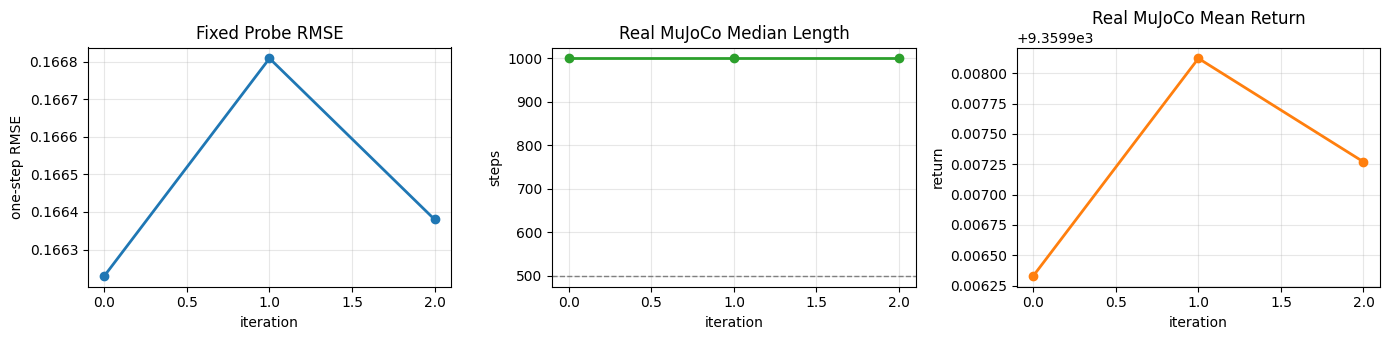

Iter 0: fixed RMSE=0.166230 | real median len=1000.0 | real mean return=9359.91
Iter 1: fixed RMSE=0.166809 | real median len=1000.0 | real mean return=9359.91
Iter 2: fixed RMSE=0.166380 | real median len=1000.0 | real mean return=9359.91

LQR verification criteria
  Target: real median episode length >= 500 steps
  Observed: 1000.0 steps
PASS: learned SINDy dynamics produce a controller that transfers to real MuJoCo.


In [15]:
iters = sorted(metrics_by_iter.keys())
fixed_rmse = [metrics_by_iter[i]["fixed_rmse"] for i in iters]
median_real_len = [real_eval_by_iter[i]["median_length"] for i in iters]
mean_real_return = [real_eval_by_iter[i]["mean_return"] for i in iters]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(iters, fixed_rmse, "o-", lw=2)
axes[0].set_title("Fixed Probe RMSE")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("one-step RMSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, median_real_len, "o-", lw=2, color="tab:green")
axes[1].axhline(500, color="gray", ls="--", lw=1)
axes[1].set_title("Real MuJoCo Median Length")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("steps")
axes[1].grid(True, alpha=0.3)

axes[2].plot(iters, mean_real_return, "o-", lw=2, color="tab:orange")
axes[2].set_title("Real MuJoCo Mean Return")
axes[2].set_xlabel("iteration")
axes[2].set_ylabel("return")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for i in iters:
    print(
        f"Iter {i}: fixed RMSE={metrics_by_iter[i]['fixed_rmse']:.6f} | "
        f"real median len={real_eval_by_iter[i]['median_length']:.1f} | "
        f"real mean return={real_eval_by_iter[i]['mean_return']:.2f}"
    )

if RUN_FINAL_LQR_ASSERT:
    print("\nLQR verification criteria")
    print("  Target: real median episode length >= 500 steps")
    print(f"  Observed: {final_lqr_eval['median_length']:.1f} steps")
    assert final_lqr_eval["median_length"] >= 500, (
        "SINDy-LQR did not transfer well enough. Check geometry, fixed validation RMSE, "
        "and the learned B matrix before trying PPO."
    )
    print("PASS: learned SINDy dynamics produce a controller that transfers to real MuJoCo.")
else:
    print("Final LQR assert skipped")


## 10. PPO-In-SINDy Checkpoint Sweep

This section ports the single-pendulum lesson back to the double pendulum: PPO trained in a learned surrogate can be non-monotonic. A later checkpoint can be worse than an earlier checkpoint, so each policy is saved and evaluated in real MuJoCo.

The primary experiment is still pure PPO-in-surrogate transfer. The action penalty is only surrogate-side regularization:

\[
    r_{surrogate} = r_{task} - \lambda_u u^2
\]

It discourages large actions that may exploit SINDy rollout error, but it does not train PPO on real MuJoCo rewards.

In [16]:
def near_upright_initial_states(X, max_abs_angle=0.25, max_abs_velocity=3.0):
    """Choose PPO reset states close to the upright balancing region."""
    X = np.asarray(X, dtype=np.float64)
    mask = (
        (np.abs(X[:, 1]) <= max_abs_angle)
        & (np.abs(X[:, 2]) <= max_abs_angle)
        & (np.abs(X[:, 3]) <= max_abs_velocity)
        & (np.abs(X[:, 4]) <= max_abs_velocity)
        & (np.abs(X[:, 5]) <= max_abs_velocity)
    )
    selected = X[mask]
    if len(selected) == 0:
        print("No near-upright states found; falling back to the full dataset")
        return X
    print(f"PPO reset pool: {len(selected):,} near-upright states")
    return selected


class SINDySurrogateEnv(gym.Env):
    """Gymnasium wrapper around learned SINDy dynamics for PPO training."""
    metadata = {"render_modes": []}

    def __init__(
        self,
        sindy_model,
        initial_states,
        max_steps=PPO_SURROGATE_MAX_STEPS,
        action_penalty_lambda=0.0,
        lqr_gain=None,
        residual_scale=None,
    ):
        super().__init__()
        self.sindy_model = sindy_model
        self.initial_states = np.asarray(initial_states, dtype=np.float64)
        self.max_steps = max_steps
        self.action_penalty_lambda = float(action_penalty_lambda)
        self.lqr_gain = lqr_gain
        self.residual_scale = residual_scale
        self.observation_space = spaces.Box(
            low=-SURROGATE_STATE_LIMITS.astype(np.float32),
            high=SURROGATE_STATE_LIMITS.astype(np.float32),
            shape=(STATE_DIM,),
            dtype=np.float32,
        )
        self.action_space = spaces.Box(ACTION_LOW, ACTION_HIGH, shape=(ACTION_DIM,), dtype=np.float32)
        self.state = None
        self.steps = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx = self.np_random.integers(0, len(self.initial_states))
        self.state = self.initial_states[idx].copy()
        self.state += self.np_random.normal(0.0, PPO_RESET_NOISE_STD, size=STATE_DIM)
        self.steps = 0
        return self.state.astype(np.float32), {}

    def _controller_action(self, raw_action):
        raw_action = np.asarray(raw_action, dtype=np.float64).reshape(1)
        raw_action = np.clip(raw_action, ACTION_LOW, ACTION_HIGH)
        if self.lqr_gain is None or self.residual_scale is None:
            return raw_action
        lqr_action = float(action_from_lqr(self.lqr_gain, self.state)[0])
        residual = float(raw_action[0])
        combined = np.clip(lqr_action + self.residual_scale * residual, ACTION_LOW, ACTION_HIGH)
        return np.asarray([combined], dtype=np.float64)

    def step(self, action):
        action = self._controller_action(action)
        self.state = sindy_next(self.sindy_model, self.state, action[0])
        reward, tip_failed = reward_done_from_state6(self.state)

        # Surrogate-side action regularization. This is not direct real-env training.
        reward -= self.action_penalty_lambda * float(action[0] ** 2)

        outside_support = np.any(np.abs(self.state) > SURROGATE_STATE_LIMITS)
        invalid_state = not np.all(np.isfinite(self.state))
        terminated = bool(tip_failed or outside_support or invalid_state)
        if outside_support or invalid_state:
            reward -= 100.0

        self.steps += 1
        truncated = self.steps >= self.max_steps
        info = {
            "tip_height": tip_position_from_state6(self.state)[1] if not invalid_state else np.nan,
            "outside_support": bool(outside_support),
            "action_penalty_lambda": self.action_penalty_lambda,
        }
        return self.state.astype(np.float32), float(reward), terminated, truncated, info


def make_ppo_model(env):
    """Create a PPO model with the same hyperparameters for every sweep condition."""
    return PPO(
        "MlpPolicy",
        env,
        learning_rate=PPO_LEARNING_RATE,
        n_steps=PPO_N_STEPS,
        batch_size=PPO_BATCH_SIZE,
        n_epochs=PPO_N_EPOCHS,
        gamma=PPO_GAMMA,
        ent_coef=PPO_ENT_COEF,
        verbose=0,
    )


def checkpoint_path_for(lambda_u, target_step, actual_step=None, residual_scale=None):
    """Create a stable checkpoint filename for PPO sweep runs."""
    mode = "pure" if residual_scale is None else f"residual_{residual_scale:.2f}"
    penalty = f"lambda_{lambda_u:.3f}".replace(".", "p")
    actual = f"_actual_{actual_step:05d}" if actual_step is not None else ""
    return PPO_SWEEP_DIR / mode / penalty / f"ppo_target_{int(target_step):05d}{actual}.zip"


def train_ppo_checkpoints(
    sindy_model,
    initial_states,
    action_penalty_lambda,
    checkpoint_steps=PPO_CHECKPOINT_STEPS,
    lqr_gain=None,
    residual_scale=None,
):
    """Train PPO in the surrogate and save checkpoint policies at requested steps."""
    env = Monitor(
        SINDySurrogateEnv(
            sindy_model,
            initial_states,
            action_penalty_lambda=action_penalty_lambda,
            lqr_gain=lqr_gain,
            residual_scale=residual_scale,
        )
    )
    model = make_ppo_model(env)
    checkpoint_rows = []
    last_target = 0

    for target_step in checkpoint_steps:
        requested_steps = int(target_step - last_target)
        model.learn(
            total_timesteps=requested_steps,
            reset_num_timesteps=False,
            progress_bar=False,
        )
        actual_step = int(model.num_timesteps)
        save_path = checkpoint_path_for(action_penalty_lambda, target_step, actual_step, residual_scale)
        save_path.parent.mkdir(exist_ok=True, parents=True)
        model.save(save_path)
        checkpoint_rows.append(
            {
                "lambda_u": float(action_penalty_lambda),
                "residual_scale": np.nan if residual_scale is None else float(residual_scale),
                "target_step": int(target_step),
                "actual_step": actual_step,
                "checkpoint_path": str(save_path),
            }
        )
        print(
            f"saved checkpoint | lambda={action_penalty_lambda:.3f} | "
            f"target={target_step:,} | actual={actual_step:,}"
        )
        last_target = int(target_step)

    return model, pd.DataFrame(checkpoint_rows)

In [17]:
def evaluate_real_ppo(ppo_model, n_episodes=N_EVAL_EPISODES, seed=50_000, label="PPO real eval"):
    """Evaluate a PPO policy trained on 6D SINDy states in real MuJoCo."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths, returns, actions = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs).astype(np.float32)
            action, _ = ppo_model.predict(state, deterministic=True)
            action = np.asarray(action, dtype=np.float32).reshape(1)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)
            actions.append(float(action[0]))

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    result = summarize_lengths_returns(lengths, returns, label)
    result["mean_abs_action"] = float(np.mean(np.abs(actions))) if actions else np.nan
    result["max_abs_action"] = float(np.max(np.abs(actions))) if actions else np.nan
    return result


def evaluate_real_residual_ppo(
    ppo_model,
    K,
    residual_scale,
    n_episodes=N_EVAL_EPISODES,
    seed=70_000,
    label="Residual PPO real eval",
):
    """Evaluate u = clip(u_lqr + residual_scale * u_ppo) in real MuJoCo."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths, returns, actions = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            residual, _ = ppo_model.predict(state.astype(np.float32), deterministic=True)
            u_lqr = float(action_from_lqr(K, state)[0])
            u = np.clip(u_lqr + residual_scale * float(np.asarray(residual).reshape(1)[0]), ACTION_LOW, ACTION_HIGH)
            action = np.asarray([u], dtype=np.float32)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)
            actions.append(float(action[0]))

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    result = summarize_lengths_returns(lengths, returns, label)
    result["mean_abs_action"] = float(np.mean(np.abs(actions))) if actions else np.nan
    result["max_abs_action"] = float(np.max(np.abs(actions))) if actions else np.nan
    return result


def checkpoint_eval_row(result, lambda_u, target_step, actual_step, checkpoint_path, residual_scale=np.nan):
    """Flatten one real-eval result into a row for sweep tables."""
    return {
        "lambda_u": float(lambda_u),
        "residual_scale": residual_scale,
        "target_step": int(target_step),
        "actual_step": int(actual_step),
        "mean_length": result["mean_length"],
        "median_length": result["median_length"],
        "success_pct": result["survive_999_pct"],
        "mean_return": result["mean_return"],
        "mean_abs_action": result.get("mean_abs_action", np.nan),
        "max_abs_action": result.get("max_abs_action", np.nan),
        "checkpoint_path": str(checkpoint_path),
    }


def load_ppo_checkpoint(path):
    """Load a PPO checkpoint from disk."""
    return PPO.load(str(path))


ppo_sweep_checkpoints = pd.DataFrame()
ppo_sweep_results = pd.DataFrame()
ppo_model = None
ppo_real_eval = None
best_ppo_row = None
best_ppo_model = None

if RUN_PPO_AFTER_LQR and RUN_PPO_CHECKPOINT_SWEEP:
    if final_lqr_eval["median_length"] < 500:
        print("Skipping PPO because the LQR transfer gate did not pass.")
    else:
        ppo_initial_states = near_upright_initial_states(X_all)
        checkpoint_tables = []
        result_rows = []

        for lambda_u in PPO_ACTION_PENALTY_SWEEP:
            print("\n" + "=" * 78)
            print(f"Pure PPO-in-SINDy sweep | lambda_u={lambda_u:.3f}")
            ppo_model_i, checkpoint_table_i = train_ppo_checkpoints(
                final_sindy_model,
                ppo_initial_states,
                action_penalty_lambda=lambda_u,
            )
            checkpoint_tables.append(checkpoint_table_i)

            for row_idx, row in checkpoint_table_i.iterrows():
                checkpoint_model = load_ppo_checkpoint(row["checkpoint_path"])
                result = evaluate_real_ppo(
                    checkpoint_model,
                    n_episodes=PPO_CHECKPOINT_EVAL_EPISODES,
                    seed=50_000 + int(lambda_u * 100_000) + int(row["target_step"]),
                    label=f"PPO lambda={lambda_u:.3f} step={int(row['target_step'])}",
                )
                result_rows.append(
                    checkpoint_eval_row(
                        result,
                        lambda_u=lambda_u,
                        target_step=row["target_step"],
                        actual_step=row["actual_step"],
                        checkpoint_path=row["checkpoint_path"],
                    )
                )

        ppo_sweep_checkpoints = pd.concat(checkpoint_tables, ignore_index=True)
        ppo_sweep_results = pd.DataFrame(result_rows).sort_values(
            ["mean_length", "success_pct", "mean_return"],
            ascending=False,
        )
        ppo_sweep_checkpoints.to_csv(PPO_SWEEP_DIR / "ppo_checkpoint_table.csv", index=False)
        ppo_sweep_results.to_csv(PPO_SWEEP_DIR / "ppo_real_eval_results.csv", index=False)

        display(ppo_sweep_results.round(3))
        best_ppo_row = ppo_sweep_results.iloc[0]
        best_ppo_model = load_ppo_checkpoint(best_ppo_row["checkpoint_path"])
        ppo_model = best_ppo_model
        ppo_real_eval = evaluate_real_ppo(
            ppo_model,
            n_episodes=N_EVAL_EPISODES,
            seed=90_000,
            label="Best PPO checkpoint real eval",
        )
        print("\nBest pure PPO checkpoint:")
        display(best_ppo_row.to_frame().T)
elif RUN_PPO_AFTER_LQR:
    print("PPO checkpoint sweep skipped by RUN_PPO_CHECKPOINT_SWEEP=False")
else:
    print("PPO stage skipped by RUN_PPO_AFTER_LQR=False")

PPO reset pool: 18,417 near-upright states

Pure PPO-in-SINDy sweep | lambda_u=0.000


saved checkpoint | lambda=0.000 | target=3,000 | actual=3,072


saved checkpoint | lambda=0.000 | target=6,000 | actual=6,144


saved checkpoint | lambda=0.000 | target=9,000 | actual=9,216


saved checkpoint | lambda=0.000 | target=12,000 | actual=12,288


...

saved checkpoint | lambda=0.020 | target=15,000 | actual=15,360


saved checkpoint | lambda=0.020 | target=25,000 | actual=25,600
[PPO lambda=0.020 step=3000] mean return 155.12 +/- 42.62
[PPO lambda=0.020 step=3000] mean length 17.8 | median length 17.5
[PPO lambda=0.020 step=3000] survive >500 steps 0% | reach time limit 0%
[PPO lambda=0.020 step=3000] lengths: [14, 12, 16, 12, 20, 15, 24, 19, 20, 26]
[PPO lambda=0.020 step=6000] mean return 109.30 +/- 19.79
[PPO lambda=0.020 step=6000] mean length 12.9 | median length 13.0
[PPO lambda=0.020 step=6000] survive >500 steps 0% | reach time limit 0%
[PPO lambda=0.020 step=6000] lengths: [13, 16, 12, 10, 13, 11, 13, 15, 16, 10]
[PPO lambda=0.020 step=9000] mean return 130.40 +/- 32.76
[PPO lambda=0.020 step=9000] mean length 15.2 | median length 15.0
[PPO lambda=0.020 step=9000] survive >500 steps 0% | reach time limit 0%
[PPO lambda=0.020 step=9000] lengths: [13, 15, 15, 15, 13, 12, 25, 12, 16, 16]
[PPO lambda=0.020 step=12000] mean return 115.59 +/- 21.72
[PPO lambda=0.020 step=12000] mean length 13.6

,lambda_u,residual_scale,target_step,actual_step,mean_length,median_length,success_pct,mean_return,mean_abs_action,max_abs_action,checkpoint_path
24,0.020,NaN,3000,3072,17.8,17.5,0.0,155.122,0.071,0.792,/Users/andrewfalcone/Documents/Education/UW_AI...
7,0.001,NaN,6000,6144,17.2,15.0,0.0,149.371,0.267,1.000,/Users/andrewfalcone/Documents/Education/UW_AI...
19,0.010,NaN,6000,6144,16.1,15.5,0.0,138.982,0.620,1.000,/Users/andrewfalcone/Documents/Education/UW_AI...
12,0.005,NaN,3000,3072,15.9,14.5,0.0,136.822,0.127,0.656,/Users/andrewfalcone/Documents/Education/UW_AI...
6,0.001,NaN,3000,3072,15.2,14.5,0.0,130.765,0.077,0.718,/Users/andrewfalcone/Documents/Education/UW_AI...
1,0.000,NaN,6000,6144,15.2,14.0,0.0,130.651,0.461,0.809,/Users/andrewfalcone/Documents/Education/UW_AI...
26,0.020,NaN,9000,9216,15.2,15.0,0.0,130.401,0.750,1.000,/Users/andrewfalcone/Documents/Education/UW_AI...
9,0.001,NaN,12000,12288,15.2,15.0,0.0,130.219,0.638,1.000,/Users/andrewfalcone/Documents/Education/UW_AI...
0,0.000,NaN,3000,3072,15.0,13.5,0.0,129.068,0.047,0.149,/Users/andrewfalcone/Documents/Education/UW_AI...
8,0.001,NaN,9000,9216,14.4,14.0,0.0,123.001,0.631,1.000,/Users/andrewfalcone/Documents/Education/UW_AI...


[Best PPO checkpoint real eval] mean return 147.34 +/- 57.64
[Best PPO checkpoint real eval] mean length 17.0 | median length 14.5
[Best PPO checkpoint real eval] survive >500 steps 0% | reach time limit 0%
[Best PPO checkpoint real eval] lengths: [13, 16, 17, 11, 12, 13, 11, 25, 22, 30]

Best pure PPO checkpoint:


,lambda_u,residual_scale,target_step,actual_step,mean_length,median_length,success_pct,mean_return,mean_abs_action,max_abs_action,checkpoint_path
24,0.02,NaN,3000,3072,17.8,17.5,0.0,155.121985,0.071101,0.791937,/Users/andrewfalcone/Documents/Education/UW_AI...


## 10b. Optional Residual PPO Fallback

This is not the primary project claim. It only runs if `RUN_RESIDUAL_PPO_FALLBACK = True`.

Residual PPO uses LQR as a stable baseline and lets PPO learn a small correction:

\[
    u = \mathrm{clip}(u_{LQR} + \alpha u_{PPO}, -1, 1)
\]

where `alpha` is `residual_scale`. This is useful if pure PPO-in-surrogate still fails but you want to test whether surrogate-trained PPO can improve robustness around a validated controller.

In [18]:
residual_sweep_results = pd.DataFrame()

if RUN_RESIDUAL_PPO_FALLBACK and best_ppo_model is None and final_lqr_eval["median_length"] >= 500:
    print("Running residual PPO fallback because pure PPO did not produce a selected best model.")
    ppo_initial_states = near_upright_initial_states(X_all)
    result_rows = []

    for residual_scale in RESIDUAL_SCALES:
        print("\n" + "=" * 78)
        print(f"Residual PPO sweep | residual_scale={residual_scale:.2f}")
        residual_model, residual_checkpoints = train_ppo_checkpoints(
            final_sindy_model,
            ppo_initial_states,
            action_penalty_lambda=RESIDUAL_ACTION_PENALTY_LAMBDA,
            lqr_gain=final_lqr_gain,
            residual_scale=residual_scale,
        )
        final_checkpoint = residual_checkpoints.iloc[-1]
        result = evaluate_real_residual_ppo(
            load_ppo_checkpoint(final_checkpoint["checkpoint_path"]),
            final_lqr_gain,
            residual_scale=residual_scale,
            n_episodes=N_EVAL_EPISODES,
            seed=100_000 + int(100 * residual_scale),
            label=f"Residual PPO scale={residual_scale:.2f}",
        )
        result_rows.append(
            checkpoint_eval_row(
                result,
                lambda_u=RESIDUAL_ACTION_PENALTY_LAMBDA,
                target_step=final_checkpoint["target_step"],
                actual_step=final_checkpoint["actual_step"],
                checkpoint_path=final_checkpoint["checkpoint_path"],
                residual_scale=float(residual_scale),
            )
        )

    residual_sweep_results = pd.DataFrame(result_rows).sort_values("mean_length", ascending=False)
    residual_sweep_results.to_csv(PPO_SWEEP_DIR / "residual_ppo_real_eval_results.csv", index=False)
    display(residual_sweep_results.round(3))
elif RUN_RESIDUAL_PPO_FALLBACK:
    print("Residual PPO fallback skipped because pure PPO selected a best model or LQR gate failed.")
else:
    print("Residual PPO fallback disabled; pure PPO-in-SINDy remains the primary experiment.")

Residual PPO fallback disabled; pure PPO-in-SINDy remains the primary experiment.


## 10c. Best-Checkpoint Trace And Robustness Diagnostics

The best checkpoint is selected only after training is complete. The table below is diagnostic: it compares the best pure PPO checkpoint with SINDy-LQR under standard and perturbed real MuJoCo rollouts. It is not used as feedback during PPO training.

[SINDy-LQR | standard] mean return 9359.77 +/- 0.13
[SINDy-LQR | standard] mean length 1000.0 | median length 1000.0
[SINDy-LQR | standard] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR | standard] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
[best pure PPO | standard] mean return 118.66 +/- 25.69
[best pure PPO | standard] mean length 13.9 | median length 14.0
[best pure PPO | standard] survive >500 steps 0% | reach time limit 0%
[best pure PPO | standard] lengths: [12, 12, 13, 10, 16, 11, 15, 15, 20, 15]


[SINDy-LQR | angle_noise] mean return 9359.88 +/- 0.13
[SINDy-LQR | angle_noise] mean length 1000.0 | median length 1000.0
[SINDy-LQR | angle_noise] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR | angle_noise] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
[best pure PPO | angle_noise] mean return 118.86 +/- 31.48
[best pure PPO | angle_noise] mean length 13.9 | median length 13.0
[best pure PPO | angle_noise] survive >500 steps 0% | reach time limit 0%
[best pure PPO | angle_noise] lengths: [11, 13, 13, 14, 22, 10, 13, 13, 18, 12]


[SINDy-LQR | velocity_noise] mean return 7513.07 +/- 3693.38
[SINDy-LQR | velocity_noise] mean length 803.0 | median length 1000.0
[SINDy-LQR | velocity_noise] survive >500 steps 80% | reach time limit 80%
[SINDy-LQR | velocity_noise] lengths: [14, 1000, 16, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
[best pure PPO | velocity_noise] mean return 149.50 +/- 49.80
[best pure PPO | velocity_noise] mean length 17.2 | median length 16.5
[best pure PPO | velocity_noise] survive >500 steps 0% | reach time limit 0%
[best pure PPO | velocity_noise] lengths: [21, 24, 15, 27, 19, 12, 18, 10, 11, 15]


[SINDy-LQR | action_noise] mean return 9359.40 +/- 0.12
[SINDy-LQR | action_noise] mean length 1000.0 | median length 1000.0
[SINDy-LQR | action_noise] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR | action_noise] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
[best pure PPO | action_noise] mean return 149.32 +/- 44.46
[best pure PPO | action_noise] mean length 17.2 | median length 16.5
[best pure PPO | action_noise] survive >500 steps 0% | reach time limit 0%
[best pure PPO | action_noise] lengths: [11, 21, 14, 28, 20, 16, 11, 16, 18, 17]


[SINDy-LQR | mid_impulse] mean return 9359.82 +/- 0.13
[SINDy-LQR | mid_impulse] mean length 1000.0 | median length 1000.0
[SINDy-LQR | mid_impulse] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR | mid_impulse] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
[best pure PPO | mid_impulse] mean return 142.18 +/- 53.00
[best pure PPO | mid_impulse] mean length 16.4 | median length 13.0
[best pure PPO | mid_impulse] survive >500 steps 0% | reach time limit 0%
[best pure PPO | mid_impulse] lengths: [12, 27, 17, 20, 13, 26, 11, 13, 13, 12]


,policy,scenario,mean_length,median_length,success_pct,mean_return,mean_abs_action,max_abs_action
0,SINDy-LQR,standard,1000.0,1000.0,100.0,9359.769,0.002,0.600
1,best pure PPO,standard,13.9,14.0,0.0,118.658,0.074,0.789
2,SINDy-LQR,angle_noise,1000.0,1000.0,100.0,9359.883,0.001,0.634
3,best pure PPO,angle_noise,13.9,13.0,0.0,118.863,0.043,0.113
4,SINDy-LQR,velocity_noise,803.0,1000.0,80.0,7513.066,0.005,1.000
5,best pure PPO,velocity_noise,17.2,16.5,0.0,149.498,0.093,0.798
6,SINDy-LQR,action_noise,1000.0,1000.0,100.0,9359.398,0.056,0.468
7,best pure PPO,action_noise,17.2,16.5,0.0,149.318,0.088,0.808
8,SINDy-LQR,mid_impulse,1000.0,1000.0,100.0,9359.815,0.003,0.521
9,best pure PPO,mid_impulse,16.4,13.0,0.0,142.182,0.038,0.192


,step,x,theta1,theta2,xdot,theta1dot,theta2dot,tip_height,action
count,23.000,23.000,23.000,23.000,23.000,23.000,23.000,23.000,23.000
mean,11.000,0.214,0.222,-0.155,0.851,0.283,-1.015,1.166,0.155
std,6.782,0.327,0.091,0.253,1.315,1.381,1.908,0.031,0.165
min,0.000,-0.022,0.074,-0.966,-0.524,-1.876,-9.204,1.047,-0.038
25%,5.500,-0.004,0.144,-0.218,-0.184,-0.003,-1.114,1.160,0.053
50%,11.000,0.039,0.227,-0.047,0.287,0.307,-0.332,1.171,0.131
75%,16.500,0.314,0.309,0.010,1.565,0.426,-0.183,1.185,0.220
max,22.000,1.010,0.334,0.043,3.880,5.970,-0.002,1.194,0.793


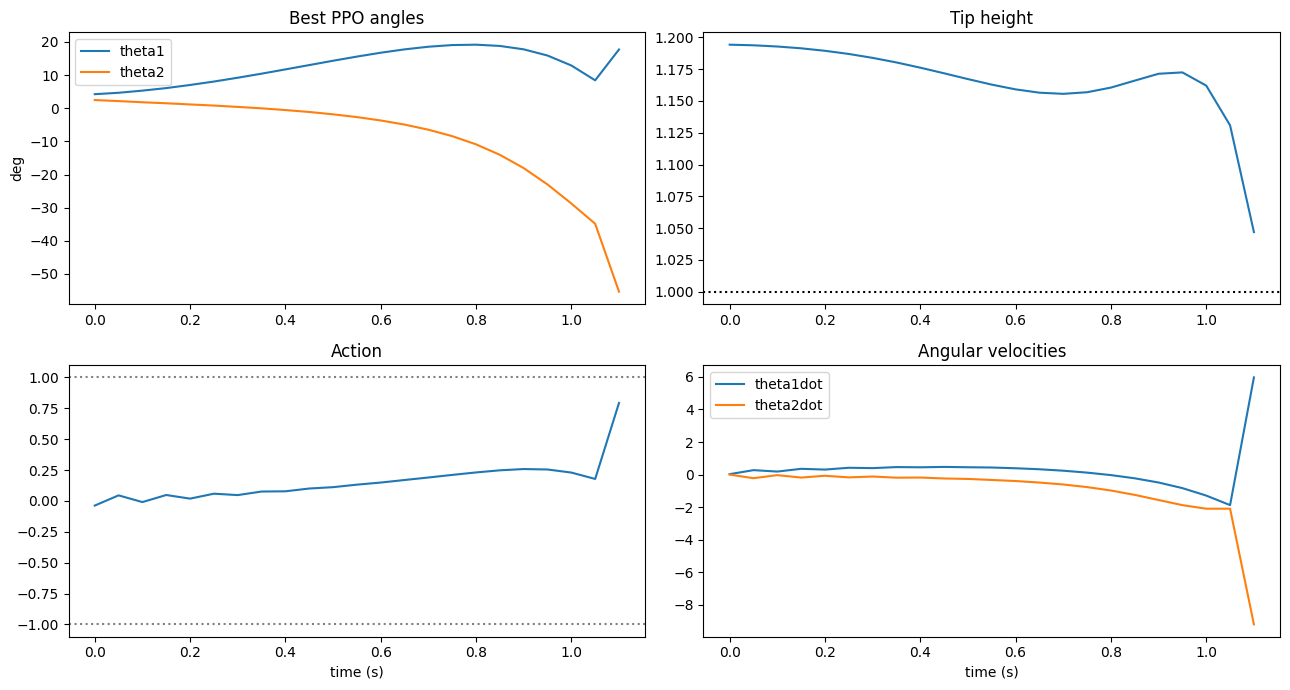

In [19]:
def apply_state_perturbation(env, obs, angle_noise=0.0, velocity_noise=0.0, rng=None):
    """Perturb MuJoCo qpos/qvel after reset for robustness evaluation."""
    rng = np.random.default_rng() if rng is None else rng
    state = obs_to_state6(obs)
    state[1:3] += rng.normal(0.0, angle_noise, size=2)
    state[3:6] += rng.normal(0.0, velocity_noise, size=3)
    env.unwrapped.set_state(state[:3], state[3:])
    return env.unwrapped._get_obs()


def evaluate_real_policy_with_scenario(policy_fn, scenario, n_episodes=ROBUSTNESS_EVAL_EPISODES, seed=120_000, label="policy"):
    """Evaluate any real-env policy function under one robustness scenario."""
    lengths, returns, actions = [], [], []
    rng = np.random.default_rng(seed)

    for ep in range(n_episodes):
        env = gym.make("InvertedDoublePendulum-v5")
        obs, _ = env.reset(seed=seed + ep)
        obs = apply_state_perturbation(
            env,
            obs,
            angle_noise=scenario["angle_noise"],
            velocity_noise=scenario["velocity_noise"],
            rng=rng,
        )
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            action = np.asarray(policy_fn(state), dtype=np.float32).reshape(1)
            if scenario["action_noise"] > 0.0:
                action += rng.normal(0.0, scenario["action_noise"], size=1).astype(np.float32)
            if scenario["impulse_step"] is not None and ep_len == scenario["impulse_step"]:
                action += np.asarray([scenario["impulse"]], dtype=np.float32)
            action = np.clip(action, ACTION_LOW, ACTION_HIGH).astype(np.float32)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)
            actions.append(float(action[0]))

        env.close()
        lengths.append(ep_len)
        returns.append(ep_ret)

    result = summarize_lengths_returns(lengths, returns, label)
    result["mean_abs_action"] = float(np.mean(np.abs(actions))) if actions else np.nan
    result["max_abs_action"] = float(np.max(np.abs(actions))) if actions else np.nan
    return result


def lqr_policy_fn(state):
    return action_from_lqr(final_lqr_gain, state)


def ppo_policy_fn(state):
    if best_ppo_model is None:
        return np.asarray([0.0], dtype=np.float32)
    action, _ = best_ppo_model.predict(state.astype(np.float32), deterministic=True)
    return np.asarray(action, dtype=np.float32).reshape(1)


def rollout_trace_for_policy(policy_fn, seed=130_000, label="policy"):
    """Record one real rollout for trace plots."""
    env = gym.make("InvertedDoublePendulum-v5")
    obs, _ = env.reset(seed=seed)
    rows = []
    done = False

    while not done and len(rows) < 1000:
        state = obs_to_state6(obs)
        action = np.clip(np.asarray(policy_fn(state), dtype=np.float32).reshape(1), ACTION_LOW, ACTION_HIGH)
        rows.append(
            {
                "step": len(rows),
                "x": state[0],
                "theta1": state[1],
                "theta2": state[2],
                "xdot": state[3],
                "theta1dot": state[4],
                "theta2dot": state[5],
                "tip_height": tip_position_from_state6(state)[1],
                "action": float(action[0]),
            }
        )
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()
    trace = pd.DataFrame(rows)
    trace["label"] = label
    return trace


robustness_rows = []
if best_ppo_model is not None:
    for scenario_name, scenario in ROBUSTNESS_SCENARIOS.items():
        for policy_name, policy_fn in [("SINDy-LQR", lqr_policy_fn), ("best pure PPO", ppo_policy_fn)]:
            result = evaluate_real_policy_with_scenario(
                policy_fn,
                scenario,
                n_episodes=ROBUSTNESS_EVAL_EPISODES,
                seed=120_000 + 1_000 * len(robustness_rows),
                label=f"{policy_name} | {scenario_name}",
            )
            robustness_rows.append(
                {
                    "policy": policy_name,
                    "scenario": scenario_name,
                    "mean_length": result["mean_length"],
                    "median_length": result["median_length"],
                    "success_pct": result["survive_999_pct"],
                    "mean_return": result["mean_return"],
                    "mean_abs_action": result["mean_abs_action"],
                    "max_abs_action": result["max_abs_action"],
                }
            )

    robustness_results = pd.DataFrame(robustness_rows)
    robustness_results.to_csv(PPO_SWEEP_DIR / "robustness_results.csv", index=False)
    display(robustness_results.round(3))

    best_trace = rollout_trace_for_policy(ppo_policy_fn, label="best pure PPO")
    display(best_trace.describe().round(3))

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    t = best_trace["step"] * DT
    axes[0, 0].plot(t, np.degrees(best_trace["theta1"]), label="theta1")
    axes[0, 0].plot(t, np.degrees(best_trace["theta2"]), label="theta2")
    axes[0, 0].set_title("Best PPO angles")
    axes[0, 0].set_ylabel("deg")
    axes[0, 0].legend()

    axes[0, 1].plot(t, best_trace["tip_height"])
    axes[0, 1].axhline(TIP_HEIGHT_FALL_THRESHOLD, color="black", linestyle=":")
    axes[0, 1].set_title("Tip height")

    axes[1, 0].plot(t, best_trace["action"])
    axes[1, 0].axhline(ACTION_LOW, color="gray", linestyle=":")
    axes[1, 0].axhline(ACTION_HIGH, color="gray", linestyle=":")
    axes[1, 0].set_title("Action")
    axes[1, 0].set_xlabel("time (s)")

    axes[1, 1].plot(t, best_trace["theta1dot"], label="theta1dot")
    axes[1, 1].plot(t, best_trace["theta2dot"], label="theta2dot")
    axes[1, 1].set_title("Angular velocities")
    axes[1, 1].set_xlabel("time (s)")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()
else:
    robustness_results = pd.DataFrame()
    print("No best PPO checkpoint selected; robustness diagnostics skipped.")

## 11. Controller Rollout Visualization Utilities

These helpers mirror the plotting style from `notebooks/Exploratory/simulation.ipynb`, but they work with this notebook's controllers:

- `lqr`: real MuJoCo rollout using `u = -Kx`
- `ppo`: real MuJoCo rollout using the PPO policy trained on 6D SINDy states

The plots make failure modes visible: angle growth, cart drift, action saturation, reward collapse, and tip-height termination.


In [20]:
def rollout_real_controller(controller, kind, seed=0, max_steps=None, label=None):
    """Roll out one controller in real MuJoCo and record states/actions/rewards.

    Parameters
    ----------
    controller:
        LQR gain matrix for kind="lqr", or a Stable-Baselines3 PPO model for kind="ppo".
    kind:
        "lqr" or "ppo".
    seed:
        MuJoCo reset seed.
    max_steps:
        Optional early stop for plotting shorter windows.
    label:
        Optional label stored with the rollout.
    """
    env = gym.make("InvertedDoublePendulum-v5")
    obs, _ = env.reset(seed=seed)
    max_steps = env.spec.max_episode_steps if max_steps is None else max_steps

    states, actions, rewards, tip_heights = [], [], [], []
    done = False

    while not done and len(actions) < max_steps:
        state = obs_to_state6(obs)
        if kind == "lqr":
            action = action_from_lqr(controller, state)
        elif kind == "ppo":
            action, _ = controller.predict(state.astype(np.float32), deterministic=True)
            action = np.asarray(action, dtype=np.float32).reshape(1)
        else:
            raise ValueError(f"Unknown controller kind: {kind}")

        next_obs, reward, terminated, truncated, _ = env.step(action)
        states.append(state)
        actions.append(float(action[0]))
        rewards.append(float(reward))
        tip_heights.append(tip_position_from_state6(state)[1])
        obs = next_obs
        done = terminated or truncated

    env.close()
    states = np.asarray(states, dtype=np.float64)
    actions = np.asarray(actions, dtype=np.float64)
    rewards = np.asarray(rewards, dtype=np.float64)
    tip_heights = np.asarray(tip_heights, dtype=np.float64)
    time = np.arange(len(actions)) * DT
    status = "TASK COMPLETE" if len(actions) >= 1000 else "FAILED"

    rollout = {
        "label": label or kind.upper(),
        "kind": kind,
        "seed": seed,
        "time": time,
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "tip_heights": tip_heights,
        "length": int(len(actions)),
        "return": float(np.sum(rewards)),
        "status": status,
    }
    print(
        f"[{rollout['label']}] {rollout['length']} steps | "
        f"return {rollout['return']:.2f} | {status}"
    )
    return rollout


def plot_controller_rollout(rollout):
    """Plot one rollout's state, action, reward, and tip-height traces."""
    states = rollout["states"]
    time = rollout["time"]
    actions = rollout["actions"]
    rewards = rollout["rewards"]
    tip_heights = rollout["tip_heights"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    (ax_x, ax_th, ax_act), (ax_xd, ax_thd, ax_rew) = axes

    ax_x.plot(time, states[:, 0], color="steelblue", lw=1.2, label="x_cart")
    ax_x.axhline(0, color="gray", ls="--", lw=1)
    ax_x.set_xlabel("Time (s)")
    ax_x.set_ylabel("Position (m)")
    ax_x.set_title("Cart position")
    ax_x.legend(fontsize=8)

    ax_th.plot(time, np.degrees(states[:, 1]), color="darkorange", lw=1.2, label="theta1")
    ax_th.plot(time, np.degrees(states[:, 2]), color="mediumpurple", lw=1.2, label="theta2")
    ax_th.axhline(0, color="gray", ls="--", lw=1)
    ax_th.set_xlabel("Time (s)")
    ax_th.set_ylabel("Angle (deg)")
    ax_th.set_title("Pole angles")
    ax_th.legend(fontsize=8)

    ax_act.plot(time, actions, color="teal", lw=1.0)
    ax_act.axhline(1, color="gray", ls=":", lw=1)
    ax_act.axhline(-1, color="gray", ls=":", lw=1)
    ax_act.set_xlabel("Time (s)")
    ax_act.set_ylabel("Action")
    ax_act.set_title("Cart force action")

    ax_xd.plot(time, states[:, 3], color="steelblue", lw=1.0)
    ax_xd.axhline(0, color="gray", ls="--", lw=1)
    ax_xd.set_xlabel("Time (s)")
    ax_xd.set_ylabel("Velocity (m/s)")
    ax_xd.set_title("Cart velocity")

    ax_thd.plot(time, states[:, 4], color="darkorange", lw=1.0, label="theta1dot")
    ax_thd.plot(time, states[:, 5], color="mediumpurple", lw=1.0, label="theta2dot")
    ax_thd.axhline(0, color="gray", ls="--", lw=1)
    ax_thd.set_xlabel("Time (s)")
    ax_thd.set_ylabel("Angular velocity (rad/s)")
    ax_thd.set_title("Pole angular velocities")
    ax_thd.legend(fontsize=8)

    ax_rew.plot(time, rewards, color="coral", lw=1.0, label="reward")
    ax_rew_twin = ax_rew.twinx()
    ax_rew_twin.plot(time, tip_heights, color="forestgreen", lw=1.0, alpha=0.75, label="tip_height")
    ax_rew.axhline(np.mean(rewards), color="red", ls="--", lw=1.2)
    ax_rew_twin.axhline(TIP_HEIGHT_FALL_THRESHOLD, color="black", ls=":", lw=1)
    ax_rew.set_xlabel("Time (s)")
    ax_rew.set_ylabel("Step reward")
    ax_rew_twin.set_ylabel("Tip height")
    ax_rew.set_title("Reward and tip height")

    title_color = "darkgreen" if rollout["status"] == "TASK COMPLETE" else "red"
    plt.suptitle(
        f"{rollout['label']} real MuJoCo rollout - "
        f"{rollout['length']} steps, return {rollout['return']:.1f} ({rollout['status']})",
        fontsize=11,
        fontweight="bold",
        color=title_color,
    )
    plt.tight_layout()
    plt.show()


def plot_controller_comparison(rollouts):
    """Overlay key traces for multiple controller rollouts."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    (ax_len, ax_angle), (ax_action, ax_reward) = axes

    for rollout in rollouts:
        label = rollout["label"]
        t = rollout["time"]
        states = rollout["states"]
        angle_norm = np.degrees(np.sqrt(states[:, 1] ** 2 + states[:, 2] ** 2))
        cumulative_reward = np.cumsum(rollout["rewards"])

        ax_len.plot(t, rollout["tip_heights"], lw=1.4, label=label)
        ax_angle.plot(t, angle_norm, lw=1.4, label=label)
        ax_action.plot(t, rollout["actions"], lw=1.0, label=label)
        ax_reward.plot(t, cumulative_reward, lw=1.4, label=label)

    ax_len.axhline(TIP_HEIGHT_FALL_THRESHOLD, color="black", ls=":", lw=1, label="fall threshold")
    ax_len.set_title("Tip height")
    ax_len.set_xlabel("Time (s)")
    ax_len.set_ylabel("Height")
    ax_len.legend(fontsize=8)

    ax_angle.set_title("Angle error magnitude")
    ax_angle.set_xlabel("Time (s)")
    ax_angle.set_ylabel("Degrees")
    ax_angle.legend(fontsize=8)

    ax_action.axhline(1, color="gray", ls=":", lw=1)
    ax_action.axhline(-1, color="gray", ls=":", lw=1)
    ax_action.set_title("Action")
    ax_action.set_xlabel("Time (s)")
    ax_action.set_ylabel("Normalized force")
    ax_action.legend(fontsize=8)

    ax_reward.set_title("Cumulative reward")
    ax_reward.set_xlabel("Time (s)")
    ax_reward.set_ylabel("Return so far")
    ax_reward.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


[SINDy-LQR] 1000 steps | return 9359.83 | TASK COMPLETE


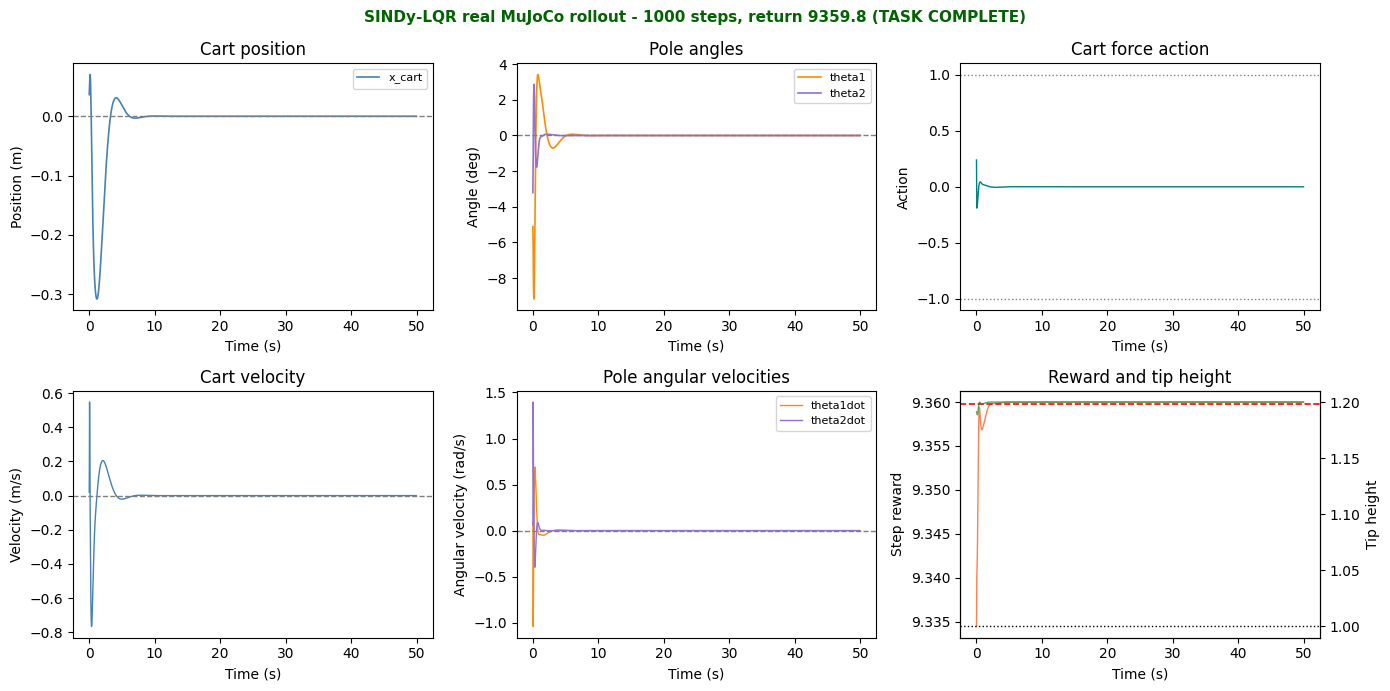

[Best PPO-on-SINDy] 13 steps | return 110.27 | FAILED


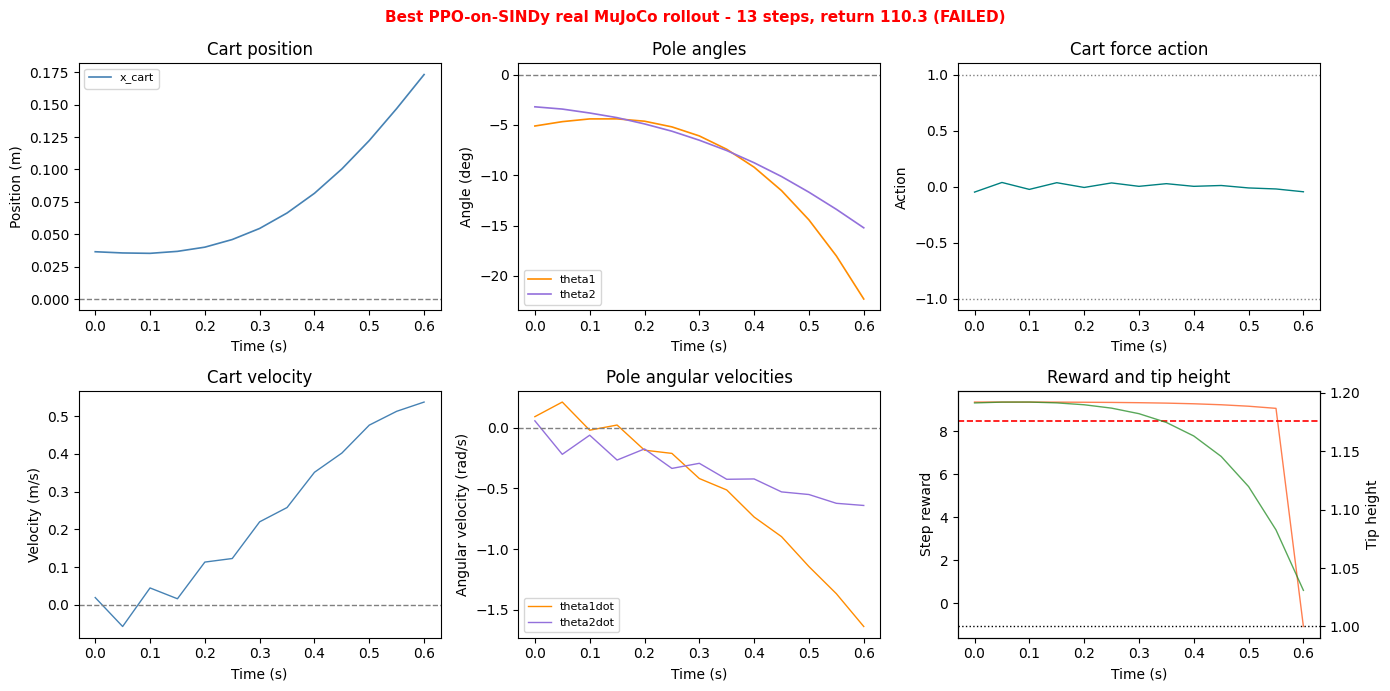

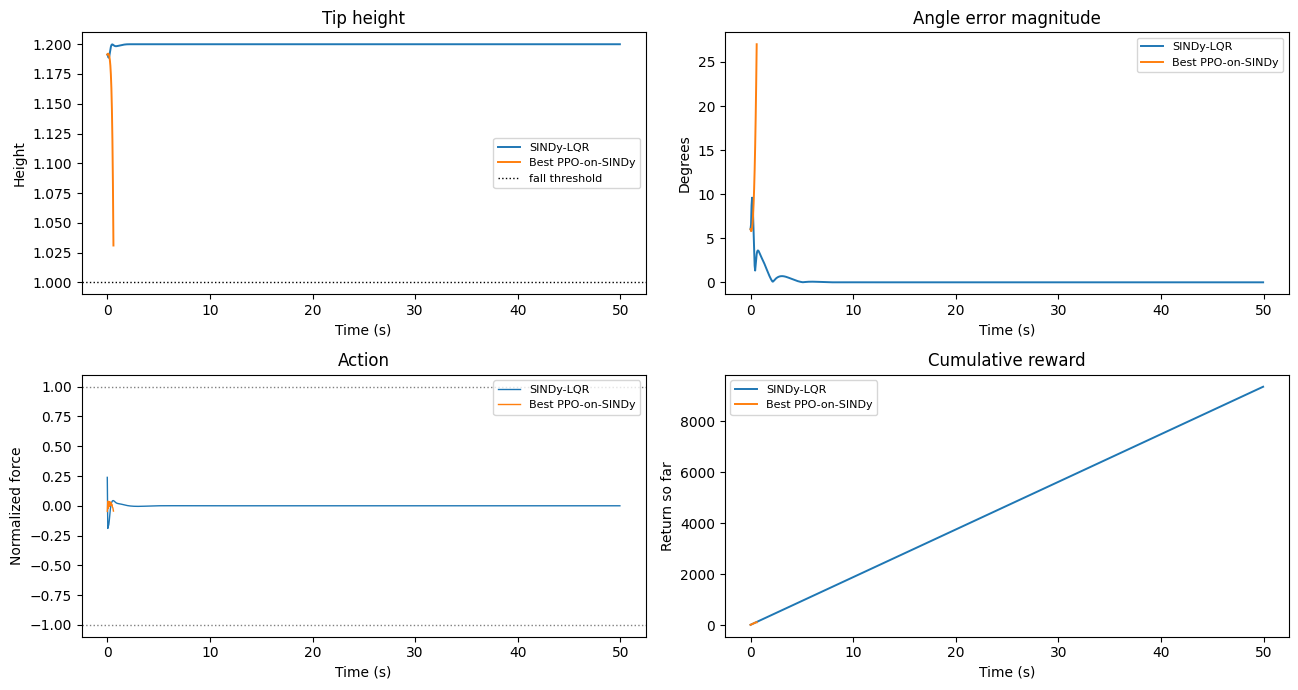

In [21]:
# Example visualizations. Run this after the LQR and optional PPO sections above.
lqr_rollout = rollout_real_controller(final_lqr_gain, kind="lqr", seed=123, label="SINDy-LQR")
plot_controller_rollout(lqr_rollout)

comparison_rollouts = [lqr_rollout]
if best_ppo_model is not None:
    ppo_rollout = rollout_real_controller(best_ppo_model, kind="ppo", seed=123, label="Best PPO-on-SINDy")
    plot_controller_rollout(ppo_rollout)
    comparison_rollouts.append(ppo_rollout)
elif ppo_model is not None:
    ppo_rollout = rollout_real_controller(ppo_model, kind="ppo", seed=123, label="PPO-on-SINDy")
    plot_controller_rollout(ppo_rollout)
    comparison_rollouts.append(ppo_rollout)
else:
    print("No PPO model selected; run the PPO checkpoint sweep first to compare PPO-on-SINDy.")

plot_controller_comparison(comparison_rollouts)

## 12. Optional Rendered Animation

This uses MuJoCo's `rgb_array` renderer. It is useful for presentation, but the trajectory plots above are usually better for debugging.


In [22]:
def animate_real_controller(controller, kind, seed=0, frame_stride=4, label="controller"):
    """Render one real MuJoCo episode as a notebook animation."""
    import matplotlib.animation as animation
    from IPython.display import HTML

    env = gym.make("InvertedDoublePendulum-v5", render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    done = False

    while not done:
        state = obs_to_state6(obs)
        if kind == "lqr":
            action = action_from_lqr(controller, state)
        elif kind == "ppo":
            action, _ = controller.predict(state.astype(np.float32), deterministic=True)
            action = np.asarray(action, dtype=np.float32).reshape(1)
        else:
            raise ValueError(f"Unknown controller kind: {kind}")
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frames.append(env.render())

    env.close()
    n_steps = len(frames) - 1
    status = "TASK COMPLETE" if n_steps >= 1000 else "FAILED"
    print(f"[{label}] rendered {n_steps} steps ({status})")

    fig, ax = plt.subplots(figsize=(4, 6))
    ax.axis("off")
    ax.set_title(f"{label}: {n_steps} steps ({status})", fontsize=9)
    image = ax.imshow(frames[0])

    def _update(i):
        image.set_data(frames[i])
        return [image]

    anim = animation.FuncAnimation(
        fig,
        _update,
        frames=range(0, len(frames), frame_stride),
        interval=50,
        blit=True,
    )
    plt.close(fig)
    return HTML(anim.to_jshtml())


# Rendering movies is intentionally opt-in because it is slow and can break
# headless nbconvert runs. Set this True after the checkpoint sweep finishes.
RUN_RENDERED_ANIMATION = False

if RUN_RENDERED_ANIMATION:
    # animate_real_controller(final_lqr_gain, kind="lqr", seed=123, label="SINDy-LQR")
    if best_ppo_model is not None:
        animate_real_controller(best_ppo_model, kind="ppo", seed=123, label="Best PPO-on-SINDy")
    elif ppo_model is not None:
        animate_real_controller(ppo_model, kind="ppo", seed=123, label="PPO-on-SINDy")
    else:
        print("No PPO model selected; run the PPO checkpoint sweep before rendering PPO playback.")
else:
    print("Rendered animation skipped. Set RUN_RENDERED_ANIMATION = True in this cell to play back the selected controller.")


Rendered animation skipped. Set RUN_RENDERED_ANIMATION = True in this cell to play back the selected controller.


## 13. Final Interpretation

Use this order when deciding what to trust:

1. Geometry check catches reward/termination mistakes.
2. Fixed validation RMSE shows one-step model quality on the same probe set each time.
3. Real SINDy-LQR evaluation shows whether the learned local dynamics can produce a real controller.
4. PPO checkpoint tables show whether PPO-in-SINDy transfer is non-monotonic.
5. Action penalty comparisons test whether surrogate-side regularization reduces exploitation.
6. Robustness diagnostics test whether PPO adds value beyond nominal LQR stabilization.

For tomorrow's project update, the most useful table is `ppo_sweep_results`: `lambda_u`, checkpoint step, real MuJoCo mean length, success percent, and mean absolute action. If all pure PPO checkpoints still fail, the result is still informative: the single pendulum showed PPO-in-SINDy can transfer, while the double pendulum likely needs better recursive surrogate fidelity, a trig-augmented library, or residual PPO around the validated LQR baseline.